## Texto to Speech - criação de áudio

conda activate orange3

https://huggingface.co/models

usaremos o Audio => Text-to-Speech

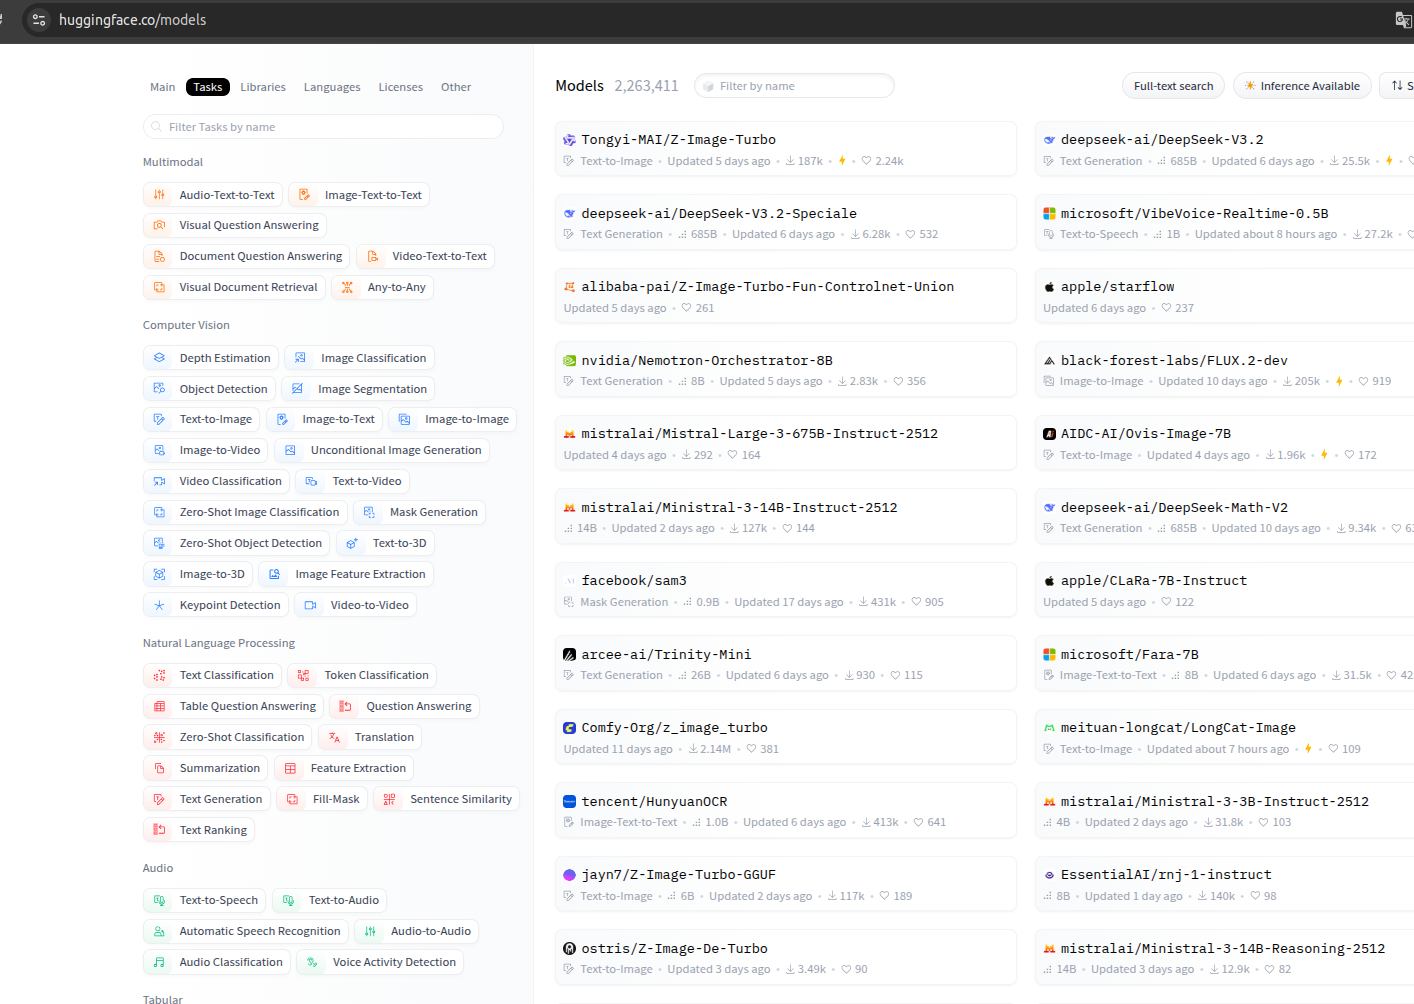

texto para gerar áudio 

Dataset, para coletar a voz para usar no hugging face

audio modelo da microsoft

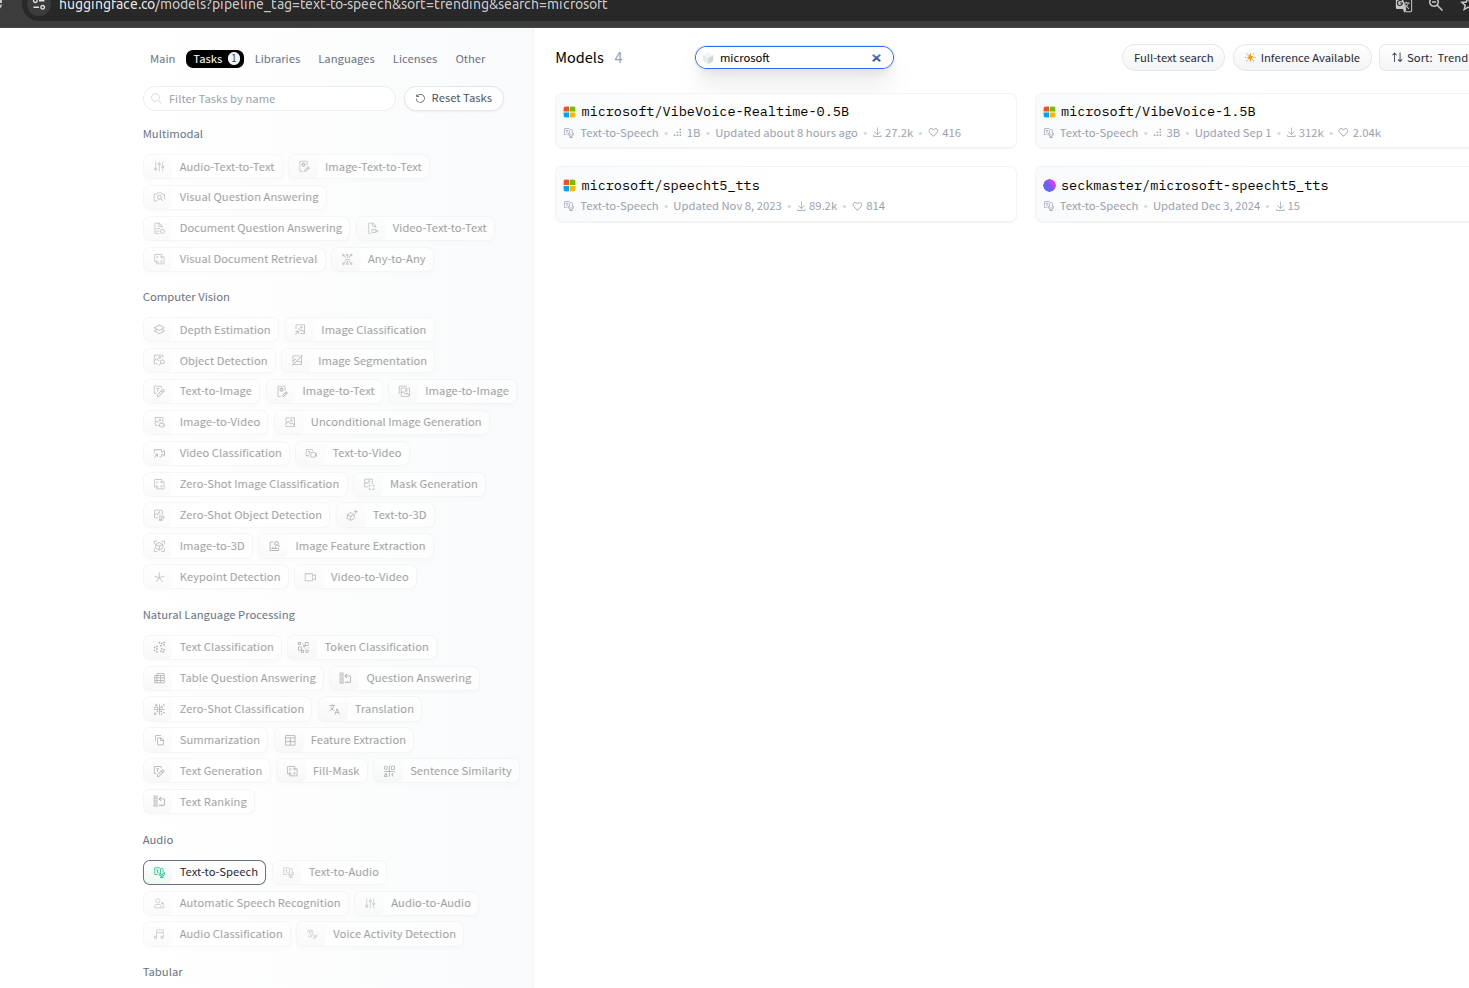

https://huggingface.co/microsoft/speecht5_tts/tree/main

pesa apenas pytorch_model.bin: 585 MB

https://huggingface.co/microsoft/speecht5_tts

In [1]:
# exemplo
# from transformers import pipeline
# from datasets import load_dataset
# import soundfile as sf

# synthesiser = pipeline("text-to-speech", "microsoft/speecht5_tts")

# embeddings_dataset = load_dataset("Matthijs/cmu-arctic-xvectors", split="validation")
# speaker_embedding = torch.tensor(embeddings_dataset[7306]["xvector"]).unsqueeze(0)
# # You can replace this embedding with your own as well.

# speech = synthesiser("Hello, my dog is cooler than you!", forward_params={"speaker_embeddings": speaker_embedding})

# sf.write("speech.wav", speech["audio"], samplerate=speech["sampling_rate"])


https://huggingface.co/microsoft/speecht5_tts?library=transformers

use this model

In [2]:
# # Load model directly
# from transformers import AutoProcessor, AutoModelForTextToSpectrogram

# processor = AutoProcessor.from_pretrained("microsoft/speecht5_tts")
# model = AutoModelForTextToSpectrogram.from_pretrained("microsoft/speecht5_tts")

In [3]:
#!pip install soundfile

In [4]:
from transformers import pipeline
from datasets import load_dataset
import soundfile as sf
import torch

/home/fabiene/anaconda3/envs/orange3/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ImportError: 

SpeechT5Tokenizer requires the SentencePiece library but it was not found in your environment. Check out the instructions on the
installation page of its repo: https://github.com/google/sentencepiece#installation and follow the ones
that match your environment. Please note that you may need to restart your runtime after installation.
    

In [5]:
#!pip install --upgrade transformers sentencepiece datasets[audio]



In [6]:
# Use a pipeline as a high-level helper
from transformers import pipeline


#modelo = pipeline("text-to-speech", "microsoft/speecht5_tts", device="cuda")
modelo_audio = pipeline("text-to-speech", model="microsoft/speecht5_tts")

Device set to use cpu


In [7]:
prompt = "Python is the best programming language. If you disagree, you're wrong"


# só isso não conclui o objetivo, dá erro precisa do sentencepiece
# resposta = modelo_audio(prompt)
# print(resposta)

In [8]:
## não rodei pip uninstall datasets -y
# rodei abaixo
#!pip install datasets==2.18.0
# Rodei a atualização datasets==3.4.1
# !pip install datasets==3.4.1

In [9]:
embeddings_dataset = load_dataset("Matthijs/cmu-arctic-xvectors", split="validation")

print(embeddings_dataset)  # duas colunas filename e xvector, o que usaremos é o xvector

Generating validation split: 100%|██████████| 7931/7931 [00:00<00:00, 83523.17 examples/s]

Dataset({
    features: ['filename', 'xvector'],
    num_rows: 7931
})


In [ ]:
# speaker_embeddings é a voz

referência áudio para audio

cmu-arctic-xvectors

https://huggingface.co/datasets/Matthijs/cmu-arctic-xvectors

diferentes vozes e sotaques

The CMU ARCTIC dataset divides the utterances among the following speakers:

bdl (US male)

slt (US female)

jmk (Canadian male)

awb (Scottish male)

rms (US male)

clb (US female)

ksp (Indian male)

### técnica sampling, samples amostras para rodar ia isto é para treinar a base de dados

In [11]:
#embeddings_dataset = load_dataset("Matthijs/cmu-arctic-xvectors", split="validation")

speaker_embedding = torch.tensor(embeddings_dataset[0]["xvector"]).unsqueeze(0) # escolhido aleatoriamente 0 ou 7306
# # You can replace this embedding with your own as well.

speech = modelo_audio(prompt, forward_params={"speaker_embeddings": speaker_embedding})
print(speech)

{'audio': array([ 0.00108168,  0.00114932,  0.0011216 , ..., -0.00359464,
       -0.00101731,  0.00105518], dtype=float32), 'sampling_rate': 16000}


In [12]:
# junta o som de cada letra, por exemplo, junta tudo e cria um texto ou audio completo

In [13]:

# speech é o gerador de modelo
# base da geração de áudio esta aqui speech["audio"], em formato de array

sf.write("speech_aulaaudioia.wav", speech["audio"], samplerate=speech["sampling_rate"])

# outra voz

In [14]:
# com outra voz

speaker_embedding = torch.tensor(embeddings_dataset[7307]["xvector"]).unsqueeze(0) # escolhido aleatoriamente 0 ou 7306
# # You can replace this embedding with your own as well.

speech = modelo_audio(prompt, forward_params={"speaker_embeddings": speaker_embedding})
print(speech)

sf.write("speech_aulaaudioia2.wav", speech["audio"], samplerate=speech["sampling_rate"])

{'audio': array([-0.00035697,  0.00062228,  0.00073594, ..., -0.00061726,
       -0.00041354, -0.00029953], dtype=float32), 'sampling_rate': 16000}


In [15]:
# voz com diferentes velocidades também

In [16]:
prompt = 'notícias do mundo' # em portugués com sotaque norte americano

speech = modelo_audio(prompt, forward_params={"speaker_embeddings": speaker_embedding})
print(speech)
sf.write("speech_aulaaudioia3.wav", speech["audio"], samplerate=speech["sampling_rate"])


{'audio': array([ 6.1366725e-04,  8.4013212e-04,  8.0990657e-04, ...,
       -6.5554335e-04, -3.6900048e-04, -8.6218839e-05], dtype=float32), 'sampling_rate': 16000}
